# Topic

This Jupyter Notebook amains to compute temperature normal based on a moving average method.<br>
The objective is to smooth the daily temperature normal computed over 30 years. 

# Imports

In [1]:
import os

from packages.mining import open_data
from packages.plotting import plot_clim_ma_compa
from packages.computing import clim_ma, clim_ma_compa, ma_quantiles, year_vs_climato

directory = os.chdir("/home/leopaul/Climate_Change_PO/")

# Working with station data

In [2]:
sr = open_data(
    "data/FRNOR.RR2025010565429.PPDH.KEYuAAuu91dxAxu2BfU7xuA.csv",
    "T"
)

/home/leopaul/Climate_Change_PO/packages/mining.py:23: DtypeWarning: Columns (2,3,6,7,9,10,11,13,17,18,19,21,23,24,25,27,29,40,41,45,49,51,53,55,57,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, sep=';', encoding='utf-8')


DatetimeIndex(['1930-08-01 00:00:00', '1930-08-01 03:00:00',
               '1930-08-01 06:00:00', '1930-08-01 09:00:00',
               '1930-08-01 12:00:00', '1930-08-01 15:00:00',
               '1930-08-01 21:00:00', '1930-08-02 00:00:00',
               '1930-08-02 03:00:00', '1930-08-02 06:00:00',
               ...
               '2025-06-28 03:00:00', '2025-06-28 06:00:00',
               '2025-06-28 09:00:00', '2025-06-28 12:00:00',
               '2025-06-28 15:00:00', '2025-06-28 18:00:00',
               '2025-06-28 21:00:00', '2025-06-29 00:00:00',
               '2025-06-29 03:00:00', '2025-06-29 06:00:00'],
              dtype='datetime64[ns]', name='DATE', length=46323, freq=None)


In [3]:
sr_stdy = sr.loc["1960-01-01 00:00:00":"2024-12-31 23:00:00"].resample("D").mean()
dates_nan = sr_stdy[sr_stdy.isna()].index
nan_by_year = sr_stdy.isna().groupby(sr_stdy.index.year).sum()
nan_by_year = nan_by_year[nan_by_year != 0]
print(nan_by_year)
print(dates_nan)

DATE
2019    7
Name: T, dtype: int64
DatetimeIndex(['2019-07-08', '2019-07-09', '2019-07-10', '2019-07-11',
               '2019-07-27', '2019-07-28', '2019-08-18'],
              dtype='datetime64[ns]', name='DATE', freq=None)


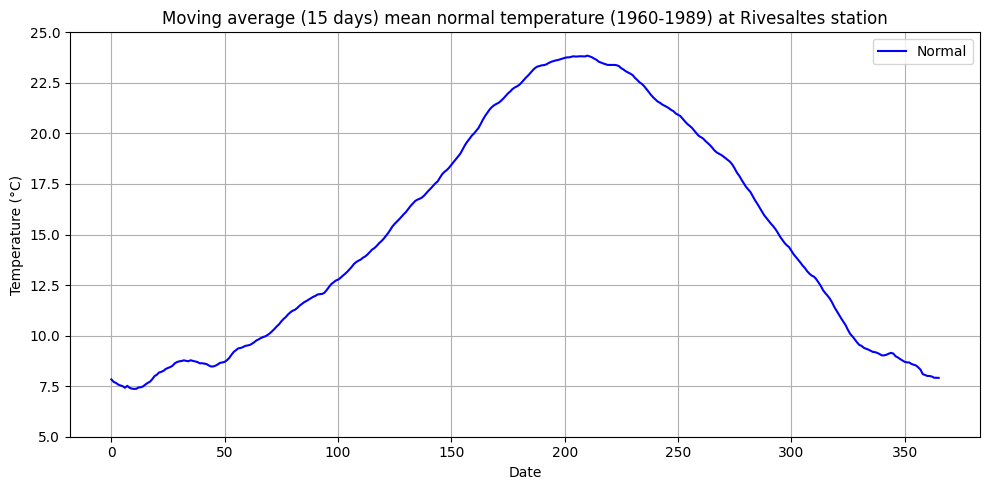

In [4]:
sr_nrm = clim_ma(
    sr,
    "temperature",
    15,
    "mean",
    "1960-01-01 00:00:00",
    "1989-12-31 23:00:00",
    "temp/station",
    True
)

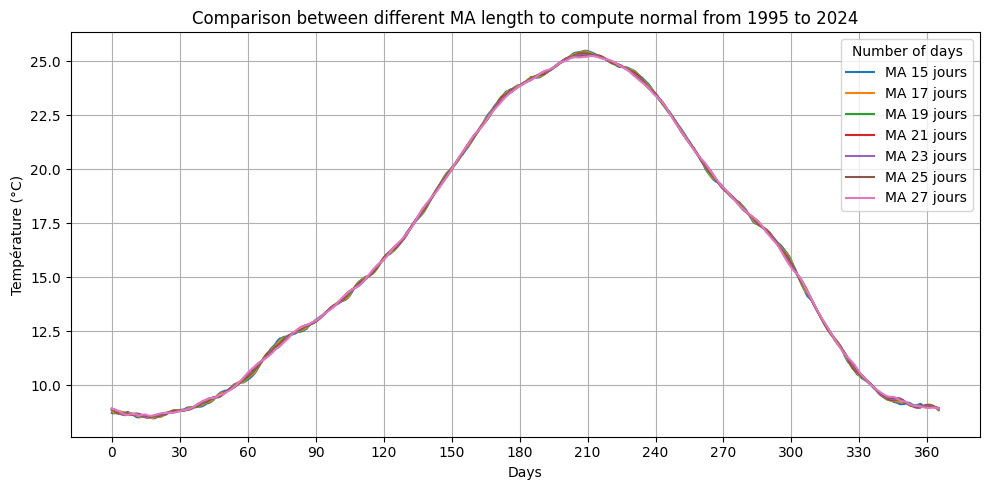

In [6]:
dic_nrms = clim_ma_compa(
    sr,
    "temperature",
    (15, 29, 2),
    "mean",
    "1995-01-01 00:00:00",
    "2024-12-31 23:00:00",
)

plot_clim_ma_compa(
    dic_nrms, 
    "1995",
    "2024",
    True
)

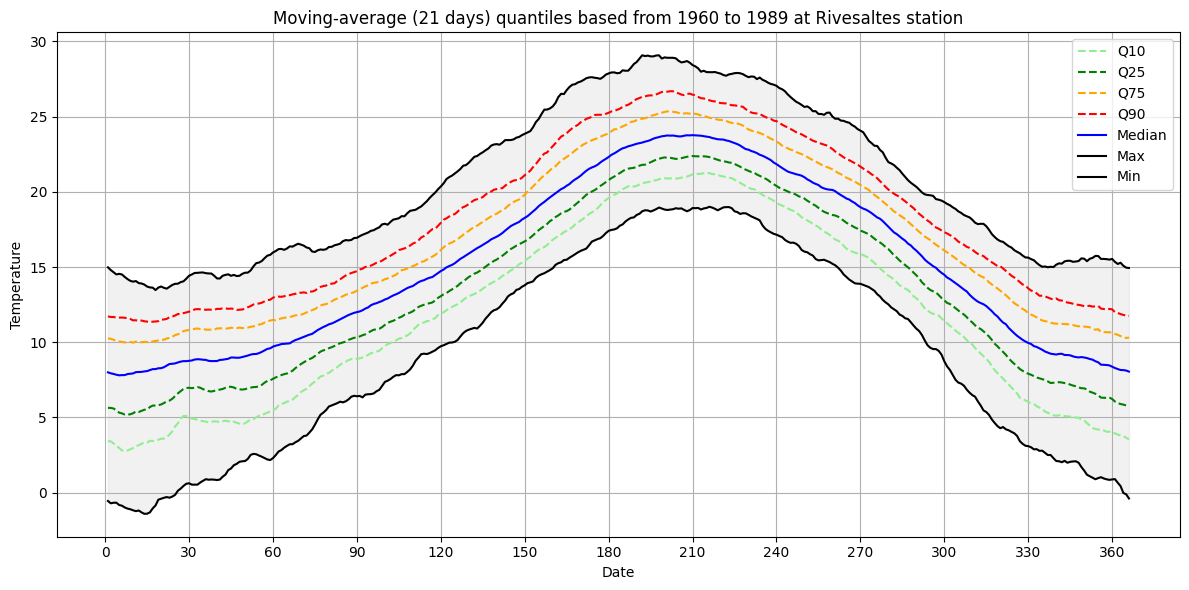

In [7]:
dic_ma_q = ma_quantiles(
    sr,
    21,
    "avg",
    "1960-01-01 00:00:00",
    "1989-12-31 23:00:00",
    "Moving-average (21 days) quantiles based from 1960 to 1989 at Rivesaltes station",
    "Temperature",
    "temp/station"
)

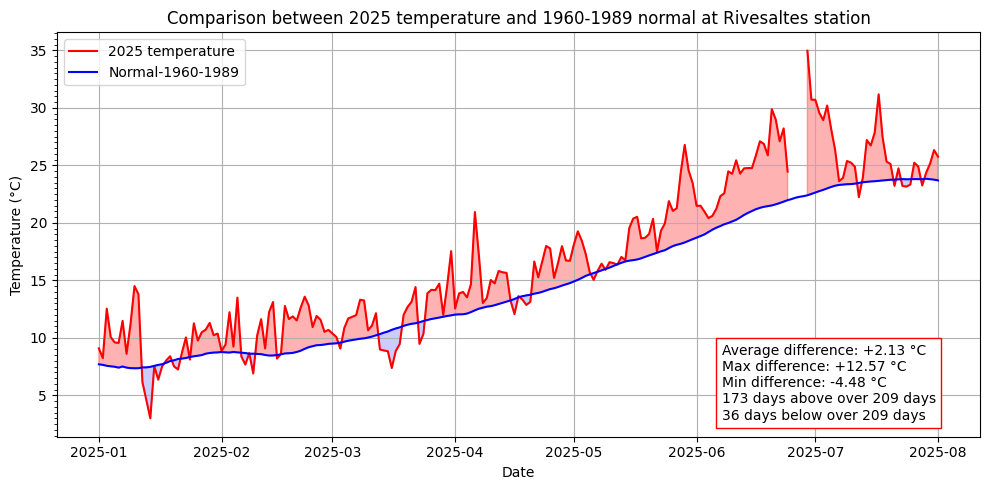

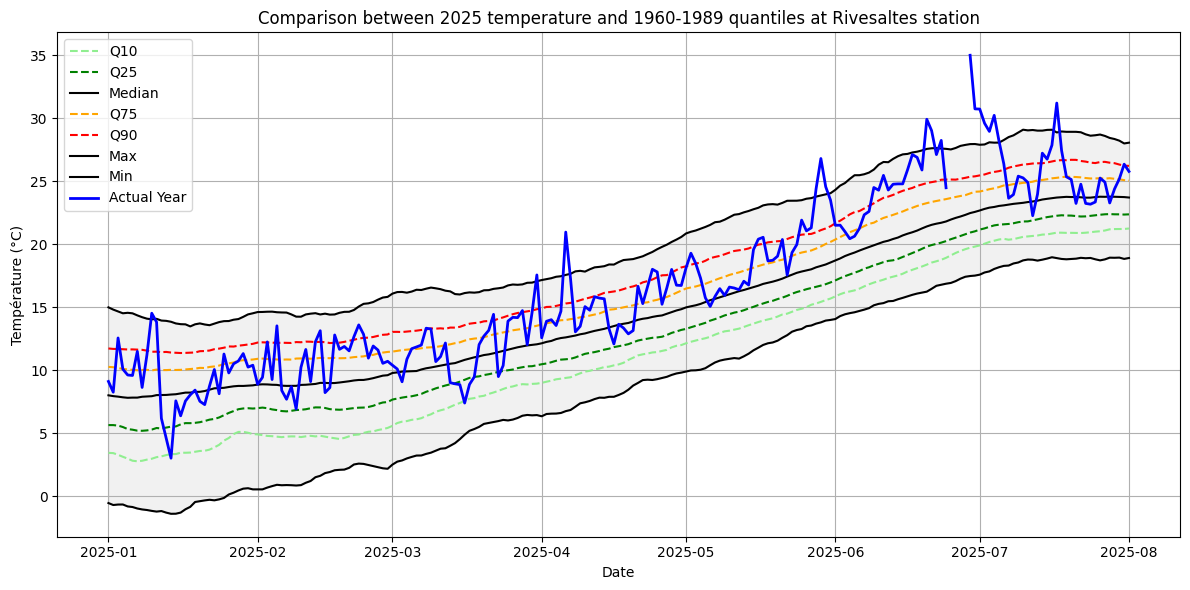

In [8]:
year_vs_climato(
    sr,
    sr_nrm,
    dic_ma_q,
    "1960-1989",
    "2025-01-01 00:00:00",
    "2025-12-31 23:00:00"
)